<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB45 · Cómo piensa MuJoCo

**Parte 6 · Simulación de bípedos a fondo — Bloque A: MuJoCo por dentro — Lección 1**

> Hasta ahora has usado MuJoCo como se usa un coche: arrancar (`MjModel`, `MjData`), acelerar (`mj_step`) y mirar el velocímetro (`qpos`, `xpos`). Funciona, y con eso has hecho andar a Zancudo. Pero un ingeniero de simulación tiene que saber **qué hay debajo del capó**.

En una entrevista para un puesto de simulación o de locomoción te van a preguntar cosas como estas:

- "¿Qué diferencia hay entre `mjModel` y `mjData`?"
- "¿Por qué un robot con una articulación libre tiene `nq = 7` pero `nv = 6`?"
- "¿Qué hace exactamente `mj_step`? ¿Y `mj_forward`? ¿Cuándo usarías cada una?"
- "Escribe la ecuación del movimiento de un robot y explica cada término."
- "Si guardo el estado y vuelvo a simular, ¿sale exactamente lo mismo?"

Al final de este notebook sabrás contestar a todas, y no de memoria: **lo habrás comprobado con números**.

Empieza también hoy una forma nueva de trabajar. Me pediste que, en esta parte, el **Python** se explique a **nivel profesional**, a fondo. Así que cada notebook de la Parte 6 tiene **dos hilos** que se entrelazan:

| Hilo de MuJoCo | Hilo de Python |
|---|---|
| modelo y datos | Python como "envoltorio" de C |
| coordenadas generalizadas, estado | **vistas y copias** (el bug más común con MuJoCo) |
| el pipeline de `mj_step` | |
| la ecuación del movimiento | |
| | **type hints**, **dataclasses**, `@property`, `@classmethod`, `__repr__` |
| | diseñar una clase de verdad: `Simulacion` |

No son dos asignaturas separadas: el Python aparecerá justo cuando lo necesitemos para entender o para manejar MuJoCo.


## 1 · Dos objetos: el plano y la partida

Empecemos por lo más básico, que es también lo más importante. Cada vez que has usado MuJoCo has creado **dos** objetos:

```python
modelo = mujoco.MjModel.from_xml_path("robots/zancudo.xml")
datos = mujoco.MjData(modelo)
```

¿Por qué dos? Porque separan dos tipos de información muy distintos:

- **`MjModel`, el modelo**: todo lo que **no cambia** mientras simulas. Las masas de las piezas, sus formas y tamaños, dónde están las articulaciones y entre qué límites se mueven, cómo son los motores, el pasito de tiempo, la gravedad... Es el **plano** del robot y del mundo.
- **`MjData`, los datos**: todo lo que **cambia**. Los ángulos de las articulaciones ahora mismo, sus velocidades, el tiempo, las órdenes a los motores, y **todo lo que MuJoCo calcula** a partir de ellos: dónde está cada pieza en el espacio, qué está tocando qué, qué fuerzas hay...

Una comparación: el modelo es el **tablero y las reglas** del ajedrez; los datos son **una partida concreta**: dónde están las piezas ahora, de quién es el turno.

Esta separación tiene consecuencias muy prácticas:

1. Con **un** modelo puedes tener **muchos** datos a la vez: muchas partidas con el mismo tablero. Así se simulan muchos robots en paralelo (en el NB34 usabas 4 copias del entorno; en el NB60 usaremos miles).
2. Para "volver atrás en el tiempo" basta con guardar y restaurar **los datos**: el modelo no ha cambiado (sección 4).
3. Si cambias el **modelo** (por ejemplo, la masa del torso), cambias el robot para **todas** las partidas. Lo usaremos en el NB55 para la aleatorización de dominio.

Vamos a abrir los dos objetos de Zancudo y a mirar dentro.


In [1]:
import os
os.environ["MUJOCO_GL"] = "egl"          # dibujar sin pantalla, como siempre (NB34)

import mujoco
import numpy as np
np.set_printoptions(precision=3, suppress=True, linewidth=120)   # números más legibles (NB27)

modelo = mujoco.MjModel.from_xml_path("robots/zancudo.xml")
datos = mujoco.MjData(modelo)
print(type(modelo))
print(type(datos))

<class 'mujoco._structs.MjModel'>
<class 'mujoco._structs.MjData'>


`np.set_printoptions` cambia cómo NumPy **imprime** los arrays (no cómo los guarda): 3 decimales (`precision=3`), sin notación científica para números pequeños (`suppress=True`) y líneas de hasta 120 caracteres. Lo pondremos al principio de los notebooks de esta parte.

`type(...)` nos dice la clase de cada objeto: `mujoco._structs.MjModel` y `mujoco._structs.MjData`. Ese `_structs` esconde algo importante, y es nuestro primer tema de Python.


### Python a fondo · MuJoCo está escrito en C

MuJoCo **no** está escrito en Python. Está escrito en **C**, un lenguaje mucho más antiguo y mucho más rápido, en el que se programan los sistemas operativos, los motores de videojuegos y casi todo el software donde la velocidad importa. El paquete `mujoco` que importas en Python es un **envoltorio** (en inglés, *bindings*): una capa fina que deja a Python llamar a las funciones de C y leer su memoria.

¿Por qué se hace así? Porque cada lenguaje es bueno en una cosa:

| | C | Python |
|---|---|---|
| Velocidad | Muy rápido: se traduce a instrucciones de la CPU antes de ejecutarse (se **compila**). | Mucho más lento: se va interpretando línea a línea. |
| Comodidad | Hay que gestionar la memoria a mano, declarar los tipos de todo... | Muy cómodo, muy legible. |
| Uso típico | El "motor": los cálculos pesados. | El "volante": organizar, experimentar, entrenar. |

Este reparto es **el patrón de casi toda la computación científica**: NumPy (por dentro, C), PyTorch (C++ y CUDA), MuJoCo (C)... Python manda, y el trabajo pesado se hace en un lenguaje compilado.

Dos consecuencias que vas a notar:

- **`mj_step` es rapidísimo**, pero cada **llamada** desde Python tiene un pequeño coste fijo (pasar de Python a C y volver). Lo mediremos en la sección 10 y lo atacaremos en el NB49.
- **Los arrays de `MjData` viven en la memoria de C.** Cuando escribes `datos.qpos`, Python no te da una copia de los números: te da una **ventana** a esa memoria. Esto es tan importante (y causa tantos errores) que tiene una sección entera, la 5.


### Lo que hay en el modelo

El modelo guarda los **tamaños** del mundo en atributos que empiezan por `n` ("número de"):


In [2]:
print("cuerpos (nbody):        ", modelo.nbody)
print("articulaciones (njnt):  ", modelo.njnt)
print("geometrías (ngeom):     ", modelo.ngeom)
print("actuadores (nu):        ", modelo.nu)
print("sensores (nsensor):     ", modelo.nsensor)
print("posición (nq):          ", modelo.nq)
print("velocidad (nv):         ", modelo.nv)

cuerpos (nbody):         8
articulaciones (njnt):   9
geometrías (ngeom):      8
actuadores (nu):         6
sensores (nsensor):      2
posición (nq):           9
velocidad (nv):          9


- **8 cuerpos**: el torso, dos muslos, dos piernas, dos pies... ¡y el **mundo**, que MuJoCo cuenta como el cuerpo número 0! Es la raíz del árbol (NB42): todo cuelga de él.
- **9 articulaciones**: las 3 de la raíz plana (avanzar, subir, girar; NB42) y las 6 de las piernas.
- **8 geometrías**: el suelo y las 7 formas del robot.
- **6 actuadores** (`nu`, de la letra *u* con la que los ingenieros de control escriben "la acción"), **2 sensores** (el acelerómetro y el giróscopo, NB41).
- **`nq = 9`** y **`nv = 9`**: los números que hacen falta para describir la **posición** y la **velocidad** del robot. Aquí coinciden. En la sección 3 veremos que **no siempre** es así, y por qué.

Además de tamaños, el modelo guarda **todas** las propiedades de todas las piezas, en arrays con un prefijo que dice de qué tipo de pieza son: `body_` (cuerpos), `jnt_` (articulaciones), `geom_`, `actuator_`... Por ejemplo, las masas:


In [3]:
print(modelo.body_mass)
print("masa total:", modelo.body_mass.sum(), "kg")

[ 0.  12.   3.   2.   0.8  3.   2.   0.8]
masa total: 23.6 kg


Una masa por cuerpo, en el orden del árbol: el mundo (0 kg), el torso (12 kg), y las piezas de cada pierna (3 + 2 + 0,8 kg). En total, los **23,6 kg** que calculamos en el NB42.

Y la física del mundo está en `modelo.opt` (de *options*, la sección `<option>` del MJCF):


In [4]:
print("pasito de tiempo:", modelo.opt.timestep, "s")
print("gravedad:        ", modelo.opt.gravity)
print("integrador:      ", mujoco.mjtIntegrator(modelo.opt.integrator).name)

pasito de tiempo: 0.002 s
gravedad:         [ 0.    0.   -9.81]
integrador:       mjINT_EULER


El pasito de **0,002 s** (500 por segundo, NB42), la gravedad de 9,81 m/s² hacia abajo (−z) y el **integrador**, que es el método numérico que usa MuJoCo para avanzar en el tiempo: `mjINT_EULER`, el de Euler (el de la pelota del NB07, ¡con un pequeño truco que veremos en la sección 6!). En el NB49 compararemos los cinco integradores que tiene MuJoCo.

`mujoco.mjtIntegrator(0)` convierte el número 0 en un nombre legible. Es una **enumeración** (*enum*): una lista de valores con nombre. MuJoCo tiene muchas, todas con el prefijo `mjt`: `mjtIntegrator`, `mjtJoint` (tipos de articulación), `mjtGeom` (tipos de geometría)... Las enumeraciones de Python las veremos a fondo en el NB48.


### Acceso por nombre

Buscar las cosas por su **número** es frágil: si añades una pieza al robot, los números de todas las siguientes cambian. Por eso MuJoCo deja buscarlas por **nombre**, el `name="..."` que les pusimos en el MJCF:


In [5]:
torso = modelo.body("torso")
print("número del torso:", torso.id)
print("masa del torso:  ", torso.mass)
print("su madre:        ", modelo.body(torso.parentid[0]).name)

número del torso: 1
masa del torso:   [12.]
su madre:         world


`modelo.body("torso")` devuelve un objeto con **todas** las propiedades de ese cuerpo, ya recortadas: `torso.mass` es lo mismo que `modelo.body_mass[1]`, pero sin tener que saber que el torso es el número 1.

(¿Por qué `torso.parentid[0]` y no `torso.parentid`? Porque estos objetos devuelven siempre **arrays**, aunque sea de un solo número, y `[0]` saca ese número. Es un detalle de la forma en que está hecho el envoltorio de C.)

Lo mismo funciona con los datos. La posición del torso en el espacio:


In [6]:
mujoco.mj_forward(modelo, datos)          # calcula todo lo que se deriva del estado (sección 6)
print(datos.body("torso").xpos)

[0.    0.    0.865]


El torso está en x = 0, y = 0, z = 0,865 m: de pie, como lo construimos en el NB42. Y lo mismo con `modelo.joint("rodilla_d")`, `datos.joint("rodilla_d")`, `modelo.actuator(...)`, `datos.sensor(...)`, `modelo.geom(...)`...

Si imprimes uno de estos objetos, te enseña **todo** lo que contiene. Pruébalo con el del torso en los datos:


In [7]:
print(datos.body("torso"))

<_MjDataBodyViews
  cacc: array([ 0., -0.,  0.,  0.,  0.,  0.])
  cfrc_ext: array([0., 0., 0., 0., 0., 0.])
  cfrc_int: array([ 0.,  0.,  0., -0.,  0.,  0.])
  cinert: array([ 1.6  ,  1.6  ,  0.037,  0.   ,  0.011, -0.   , -0.033,  0.   ,  3.98 , 12.   ])
  crb: array([ 3.955,  3.848,  0.174,  0.   ,  0.048, -0.   ,  0.   ,  0.   ,  0.   , 23.6  ])
  cvel: array([0., 0., 0., 0., 0., 0.])
  id: 1
  name: 'torso'
  subtree_angmom: array([0., 0., 0.])
  subtree_com: array([0.003, 0.   , 0.783])
  subtree_linvel: array([0., 0., 0.])
  xfrc_applied: array([0., 0., 0., 0., 0., 0.])
  ximat: array([ 1.,  0.,  0.,  0., -1., -0.,  0.,  0., -1.])
  xipos: array([0.   , 0.   , 1.115])
  xmat: array([1., 0., 0., 0., 1., 0., 0., 0., 1.])
  xpos: array([0.   , 0.   , 0.865])
  xquat: array([1., 0., 0., 0.])
>


Una ficha completa: `xpos` (posición), `xquat` y `xmat` (orientación, NB46), `subtree_com` (el centro de masas de todo lo que cuelga del torso, que es el robot entero: z = 0,783 m, NB38), `cvel` (velocidades), `cfrc_ext` (fuerzas externas)... La mayoría las iremos usando a lo largo de esta parte.

Ese formato tan cómodo al imprimir lo decide un método especial de Python, `__repr__`. Al final del notebook escribiremos uno nosotros (sección 9).


## 2 · Repaso rápido: ¿qué es "calcular" en MuJoCo?

Antes de entrar en las coordenadas, una idea que ordena todo lo que sigue. En los datos hay **dos clases** de números:

1. **El estado**: los pocos números que hacen falta para saber **todo** sobre el robot en este instante. Básicamente, las posiciones de las articulaciones (`qpos`) y sus velocidades (`qvel`). Más el tiempo, y algún detalle más (sección 4).
2. **Lo calculado**: todo lo demás. Dónde está cada pieza (`xpos`), qué toca qué (`contact`), las fuerzas, las aceleraciones... Todo eso **se deduce** del estado.

Por ejemplo: si sabes los 9 números de `qpos` de Zancudo, puedes calcular dónde está su pie izquierdo (con la trigonometría del NB36: la cadena de ángulos). El pie **no** necesita guardarse aparte: es una **consecuencia**.

Eso explica la línea `mujoco.mj_forward(modelo, datos)` de la celda anterior. Al crear los datos, `qpos` está a cero, pero `xpos` todavía no se ha calculado (está a cero también). `mj_forward` **calcula todo lo que se deduce del estado**. Si te olvidas de llamarlo después de cambiar `qpos` a mano, las posiciones de las piezas estarán **desfasadas**: es un error clásico, y lo veremos en directo en la sección 6.


## 3 · Coordenadas generalizadas: por qué nq ≠ nv

### Las coordenadas de Zancudo

En el NB36 vimos que la posición de un brazo robótico se describe con los **ángulos** de sus articulaciones, no con las posiciones de cada pieza. A esos números se les llama **coordenadas generalizadas**, y se escriben con la letra **q**. Por eso en MuJoCo se llaman `qpos` (las posiciones) y `qvel` (las velocidades).

Zancudo tiene 9 articulaciones, y cada una aporta **un** número a `qpos` y **uno** a `qvel`:


In [8]:
for j in range(modelo.njnt):
    articulacion = modelo.joint(j)
    tipo = mujoco.mjtJoint(articulacion.type[0]).name
    print(f"{j}  {articulacion.name:<11} {tipo:<13} qpos[{articulacion.qposadr[0]}]   qvel[{articulacion.dofadr[0]}]")

0  raiz_x      mjJNT_SLIDE   qpos[0]   qvel[0]
1  raiz_z      mjJNT_SLIDE   qpos[1]   qvel[1]
2  raiz_giro   mjJNT_HINGE   qpos[2]   qvel[2]
3  cadera_d    mjJNT_HINGE   qpos[3]   qvel[3]
4  rodilla_d   mjJNT_HINGE   qpos[4]   qvel[4]
5  tobillo_d   mjJNT_HINGE   qpos[5]   qvel[5]
6  cadera_i    mjJNT_HINGE   qpos[6]   qvel[6]
7  rodilla_i   mjJNT_HINGE   qpos[7]   qvel[7]
8  tobillo_i   mjJNT_HINGE   qpos[8]   qvel[8]


(El `:<11` dentro de las llaves del f-string rellena con espacios hasta 11 caracteres, alineando a la izquierda, `<`: así salen las columnas rectas. Lo vimos en el NB20.)

Dos tipos de articulación:

- **`mjJNT_SLIDE`**: una **deslizadera**, que se mueve en línea recta. Las dos primeras de la raíz: avanzar (x) y subir (z). Su número en `qpos` es una distancia, en metros.
- **`mjJNT_HINGE`**: una **bisagra**, que gira alrededor de un eje. El giro del torso y las seis de las piernas. Su número es un ángulo, en radianes.

Y dos direcciones de memoria para cada una: **`qposadr`** (en qué casilla de `qpos` está su posición) y **`dofadr`** (en qué casilla de `qvel` está su velocidad). *dof* viene de *degree of freedom*, **grado de libertad**: cada forma independiente en que algo se puede mover.

En Zancudo, las dos direcciones coinciden siempre. Pero eso es una casualidad de usar solo deslizaderas y bisagras.


### El problema de los giros en 3D

Zancudo es plano (2D): su torso solo puede girar alrededor de **un** eje. Un robot de verdad, en 3D, tiene el torso **libre**: puede ir a cualquier sitio y girar de cualquier forma. ¿Cuántos números hacen falta para eso?

- Para la **posición** del centro, 3: x, y, z.
- Para la **orientación** (hacia dónde está girado)... aquí está el lío.

Para describir una orientación en 3D basta, en teoría, con **3 ángulos** (por ejemplo: cabeceo, alabeo y guiñada, los de un avión, NB41). Pero esos 3 ángulos tienen un defecto grave: en ciertas posturas **dos de ellos se confunden** y se pierde un grado de libertad. Es el famoso **bloqueo de cardán** (*gimbal lock*): le pasó a la nave Apolo 11, y los programas de ordenador que usan 3 ángulos tienen saltos y errores cerca de esas posturas.

La solución que usan MuJoCo, los videojuegos, los drones y la NASA es describir la orientación con **4 números**: un **cuaternión**. No tiene posturas problemáticas. A cambio, los 4 números no son independientes (cumplen siempre que la suma de sus cuadrados es 1). En el NB46 veremos a fondo qué es un cuaternión y cómo se usa; hoy basta con saber **que existe** y **por qué**.

Así que:

- La **posición** de un cuerpo libre necesita **7** números: 3 de posición + 4 del cuaternión.
- Pero su **velocidad** necesita solo **6**: 3 de velocidad lineal + 3 de velocidad de giro (alrededor de x, de y y de z). Para la velocidad de giro no hay ningún problema con 3 números.

Por eso, en cuanto un robot tiene un cuerpo libre, **`nq` y `nv` dejan de coincidir**. Comprobémoslo con un modelo diminuto: una caja **libre** (`freejoint`) de la que cuelga una bola con una **rótula** (`ball`, que gira en cualquier dirección, como tu hombro), de la que cuelga otra con una bisagra:


In [9]:
CADENA = '''
<mujoco>
  <worldbody>
    <body pos="0 0 1">
      <freejoint/>
      <geom type="box" size=".1 .1 .1" mass="1"/>
      <body pos="0 0 -.3">
        <joint type="ball"/>
        <geom type="sphere" size=".05"/>
        <body pos="0 0 -.3">
          <joint type="hinge" axis="0 1 0"/>
          <geom type="sphere" size=".05"/>
        </body>
      </body>
    </body>
  </worldbody>
</mujoco>
'''
cadena = mujoco.MjModel.from_xml_string(CADENA)
print("nq =", cadena.nq, "   nv =", cadena.nv)
for j in range(cadena.njnt):
    tipo = mujoco.mjtJoint(cadena.jnt_type[j]).name
    print(f"{tipo:<13} qpos desde la casilla {cadena.jnt_qposadr[j]:2d}   qvel desde la casilla {cadena.jnt_dofadr[j]:2d}")

nq = 12    nv = 10
mjJNT_FREE    qpos desde la casilla  0   qvel desde la casilla  0
mjJNT_BALL    qpos desde la casilla  7   qvel desde la casilla  6
mjJNT_HINGE   qpos desde la casilla 11   qvel desde la casilla  9


**`nq = 12` pero `nv = 10`.** Cada tipo de articulación ocupa:

| Tipo | En `qpos` | En `qvel` | Por qué |
|---|---|---|---|
| `free` (libre) | **7** (x, y, z + cuaternión) | **6** (3 lineales + 3 de giro) | orientación 3D = cuaternión |
| `ball` (rótula) | **4** (un cuaternión) | **3** (giro en 3 ejes) | orientación 3D = cuaternión |
| `hinge` (bisagra) | 1 (ángulo) | 1 | un solo eje: no hay problema |
| `slide` (deslizadera) | 1 (distancia) | 1 | |

Por eso la rótula empieza en la casilla **7** de `qpos` pero en la **6** de `qvel`, y la bisagra en la **11** y la **9**. Las direcciones de memoria se **desfasan**.

**Consecuencia práctica (y pregunta de entrevista):** nunca supongas que la articulación número `j` está en `qpos[j]`, ni que su posición y su velocidad están en la misma casilla. **Usa siempre `qposadr` y `dofadr`**, o el acceso por nombre: `datos.joint("rodilla_d").qpos`. Con un humanoide de verdad (que tiene una articulación libre en la pelvis), escribir `qpos[j]` a ciegas lee el número equivocado... y el programa no da ningún error: simplemente, hace cosas raras.

Mira cómo empieza `qpos` de esa cadena:


In [10]:
datos_cadena = mujoco.MjData(cadena)
print(datos_cadena.qpos)

[0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0.]


Las 3 primeras casillas son la posición de la caja (0, 0, 1: la `pos` del MJCF). Las 4 siguientes, su cuaternión: **(1, 0, 0, 0)**, que es el cuaternión de "**sin girar**" (como el 0 para los ángulos; NB46). Luego otro (1, 0, 0, 0) para la rótula. Y un 0, el ángulo de la bisagra.

Y otra consecuencia: como los 4 números del cuaternión están "atados" (sus cuadrados suman 1), **no** puedes sumar a `qpos` una velocidad multiplicada por el tiempo, como hacíamos con la pelota del NB07. Para avanzar un cuaternión con una velocidad de giro hay una fórmula especial; MuJoCo la tiene en la función `mj_integratePos`, y la usa por dentro en cada paso.


## 4 · El estado completo, y viajar en el tiempo

¿Qué números hacen falta exactamente para que la simulación siga **igual** a partir de un instante? Además de `qpos` y `qvel` está el tiempo (`time`) y, en modelos con actuadores que tienen memoria (filtros, músculos), el vector `act`. Zancudo no tiene ninguno así. A ese conjunto, MuJoCo lo llama el **estado físico**.

MuJoCo trae dos funciones para **guardarlo** y **restaurarlo**: `mj_getState` y `mj_setState`. Primero preguntamos cuánto ocupa con `mj_stateSize`:


In [11]:
ESTADO = mujoco.mjtState.mjSTATE_FULLPHYSICS     # qué partes queremos: toda la física
tamano = mujoco.mj_stateSize(modelo, ESTADO)
print("números en el estado:", tamano, "  =  nq + nv + 1 (el tiempo) =", modelo.nq + modelo.nv + 1)

números en el estado: 19   =  nq + nv + 1 (el tiempo) = 19


19 = 9 + 9 + 1. Hagamos un experimento de **viaje en el tiempo**. Ponemos a Zancudo en su postura agachada (NB43), simulamos 200 pasos, **guardamos**, simulamos 300 más y anotamos dónde acaba. Después **volvemos** al punto guardado y repetimos los 300 pasos. ¿Acaba exactamente en el mismo sitio?


In [12]:
mujoco.mj_resetData(modelo, datos)                    # todo a cero, como recién creado
datos.ctrl[:] = [0.3, -0.6, 0.3, 0.3, -0.6, 0.3]       # la postura agachada del NB43
for paso in range(200):
    mujoco.mj_step(modelo, datos)

guardado = np.empty(tamano)                            # un array vacío del tamaño justo
mujoco.mj_getState(modelo, datos, guardado, ESTADO)    # MuJoCo lo rellena

for paso in range(300):
    mujoco.mj_step(modelo, datos)
final_1 = datos.qpos.copy()

mujoco.mj_setState(modelo, datos, guardado, ESTADO)    # ¡atrás en el tiempo!
for paso in range(300):
    mujoco.mj_step(modelo, datos)
final_2 = datos.qpos.copy()

print("tiempo final:", round(datos.time, 3), "s")
print("¿idénticos bit a bit?", np.array_equal(final_1, final_2))

tiempo final: 1.0 s
¿idénticos bit a bit? True


**Idénticos bit a bit**: no "muy parecidos", sino **exactamente** los mismos números, hasta el último decimal. MuJoCo es **determinista**: con el mismo estado de partida y las mismas órdenes, da siempre el mismo resultado (en el mismo ordenador y con la misma versión; NB49).

Fíjate en el estilo de `mj_getState`: no **devuelve** el estado, sino que **rellena** un array que le pasamos (`guardado`). Es típico de las bibliotecas escritas en C: el que llama prepara la memoria, y la función escribe en ella. Así no se crea memoria nueva en cada llamada, que es lento. Lo verás en muchas funciones de MuJoCo (`mj_fullM`, `mj_jac`...).

¿Para qué sirve viajar en el tiempo? Para mucho más de lo que parece:

- **Depurar**: si el robot hace algo raro en el segundo 7, guardas el estado en el segundo 6 y repites ese trozo las veces que quieras.
- **Planificar**: probar varias acciones desde el mismo punto y quedarte con la mejor (así funcionan los controladores predictivos, MPC, que veremos por encima en el NB52).
- **Comparar** dos políticas desde exactamente la misma situación.
- **Reproducibilidad** de los experimentos: imprescindible en investigación.

### Un matiz de experto: el warmstart

¿Basta **siempre** con `qpos`, `qvel` y `time` para repetir una simulación bit a bit? Casi. Hay un detalle escondido. Para calcular las fuerzas de contacto, MuJoCo resuelve un problema de optimización **por iteraciones** (sección 6 y NB48): parte de una **suposición inicial** y la va mejorando. Y esa suposición inicial es la aceleración del paso **anterior** (`qacc_warmstart`, "arranque en caliente"): así converge en muy pocas iteraciones, porque de un paso al siguiente casi nada cambia.

Si restauras el estado sin restaurar el warmstart, el solucionador arranca desde otro sitio y puede acabar en una solución que difiere en el **último decimal** (del orden de 10⁻¹⁸). En el experimento de arriba hemos tenido suerte y ha salido idéntico; en el ejercicio E6 verás un caso en que no. Por eso `mj_getState` acepta **qué partes** guardar:

| Opción | Números (Zancudo) | Qué guarda |
|---|---|---|
| `mjSTATE_PHYSICS` | 18 | `qpos`, `qvel`, `act` (y alguna cosa más que Zancudo no tiene) |
| `mjSTATE_FULLPHYSICS` | 19 | lo anterior + el tiempo |
| `mjSTATE_INTEGRATION` | 91 | **todo** lo que influye en el siguiente paso: lo anterior + las órdenes (`ctrl`), las fuerzas aplicadas a mano, el **warmstart**... |

**Regla para la entrevista:** para reproducibilidad **bit a bit garantizada**, guarda `mjSTATE_INTEGRATION`. Para casi todo lo demás (empezar episodios desde estados guardados, por ejemplo), basta con la física.

¿Y las dos líneas con `.copy()` del experimento? Son la clave de la sección siguiente.


## 5 · Python a fondo: vistas y copias

### El bug de la trayectoria repetida

Este es, probablemente, el error más común de quien empieza con MuJoCo. Queremos guardar la trayectoria de Zancudo: su `qpos` en cada paso. Lo natural es:


In [13]:
mujoco.mj_resetData(modelo, datos)
trayectoria = []
for paso in range(3):
    mujoco.mj_step(modelo, datos)
    trayectoria.append(datos.qpos)          # guardamos la posición de este paso... ¿seguro?

for i, q in enumerate(trayectoria):
    print(f"paso {i}: altura de la raíz = {q[1]:.8f}")

paso 0: altura de la raíz = -0.00023544
paso 1: altura de la raíz = -0.00023544
paso 2: altura de la raíz = -0.00023544


¡Las tres alturas son **iguales**! Y no puede ser: el robot está cayendo un poquito en cada paso (la raíz baja, por eso es negativa). ¿Qué ha pasado?

Lo que hay en la lista **no** son tres copias de los números. Son **tres referencias al mismo array**: el `qpos` que vive dentro de `datos`. Cuando `mj_step` lo actualiza, "los tres" cambian, porque son el mismo. Y al final todos muestran el último valor.

Comprobémoslo con dos herramientas. `is` pregunta si dos nombres señalan **el mismo objeto** (NB21), y `np.shares_memory` si dos arrays **comparten memoria**:


In [14]:
print("¿el primero y el último son el mismo objeto?", trayectoria[0] is trayectoria[2])
print("¿comparten memoria con datos.qpos?        ", np.shares_memory(trayectoria[0], datos.qpos))

¿el primero y el último son el mismo objeto?

 True
¿comparten memoria con datos.qpos?         True


### Qué es una vista

En el NB27 vimos las **vistas** de NumPy: un array que **no tiene sus propios números**, sino que mira a los de otro. Por ejemplo, `a[2:5]` es una vista de `a`: si cambias la vista, cambias `a`.

Con MuJoCo es igual, pero más extremo: `datos.qpos` es una **vista a la memoria de C** de MuJoCo. No hay ningún array "de Python" con los números: Python solo tiene una ventana que mira a donde MuJoCo los guarda. Esto es así **a propósito**, por velocidad: si cada vez que escribes `datos.qpos` se copiaran los números, todo sería mucho más lento, y escribir `datos.ctrl[:] = ...` no llegaría a MuJoCo.

La regla de oro:

> **Si quieres guardar un valor de `MjData` para más tarde, cópialo: `datos.qpos.copy()`.**

Con la copia, el bug desaparece:


In [15]:
mujoco.mj_resetData(modelo, datos)
trayectoria = []
for paso in range(3):
    mujoco.mj_step(modelo, datos)
    trayectoria.append(datos.qpos.copy())   # una FOTO de los números de ahora

for i, q in enumerate(trayectoria):
    print(f"paso {i}: altura de la raíz = {q[1]:.8f}")

paso 0: altura de la raíz = -0.00003924
paso 1: altura de la raíz = -0.00011772
paso 2: altura de la raíz = -0.00023544


Ahora sí, tres alturas distintas: el robot va cayendo (0,000039 m, luego el triple, luego el séxtuple: cae con aceleración constante, la gravedad, como la pelota del NB07; el 1-3-6 sale de la forma en que integra MuJoCo, sección 6).

¿Y escribir? Desde el NB34 hemos escrito siempre `datos.ctrl[:] = [...]`, con `[:]`. En un array normal de NumPy, la diferencia entre `a[:] = valores` y `a = valores` es enorme:

- `a[:] = valores` significa "**escribe** estos valores **dentro** del array que ya existe" (en todas sus casillas, `[:]`).
- `a = valores` significa "haz que el **nombre** `a` apunte a **otro** objeto". El array de antes queda intacto.

Con `MjData`, si `datos.ctrl = valores` hiciera lo segundo, sería un desastre: `datos.ctrl` dejaría de mirar la memoria de MuJoCo y tus órdenes nunca llegarían a los motores. Por eso los autores de MuJoCo lo han programado de forma que **las dos formas hacen lo mismo**: escribir dentro. Compruébalo:


In [16]:
ventana = datos.ctrl                    # una vista de la memoria de C
datos.ctrl = np.ones(6)                 # ¿reasigna, o escribe dentro?
print(ventana)                          # la vista de antes ve los unos: ¡ha escrito dentro!
print("¿sigue siendo la misma memoria?", np.shares_memory(ventana, datos.ctrl))

[1. 1. 1. 1. 1. 1.]
¿sigue siendo la misma memoria? True


La vista antigua ve los unos: `datos.ctrl = ...` ha **copiado** los valores **dentro** de la memoria de MuJoCo. ¿Cómo es posible, si en Python `=` siempre cambia a dónde apunta un nombre? Porque `ctrl` no es un atributo normal: es una **propiedad** con un *setter*, un método que Python llama automáticamente al asignar, y que MuJoCo ha programado para copiar. Veremos las propiedades en la sección 9.

Como copia dentro de un array de tamaño fijo, si le das un número de valores equivocado, se queja:


In [17]:
datos.ctrl = np.ones(5)                 # Zancudo tiene 6 motores, no 5

ValueError: could not broadcast input array from shape (5,) into shape (6,)

Un `ValueError`: "no se puede encajar un array de forma (5,) en uno de forma (6,)". Bien: el error salta **en el momento**, no diez minutos después con el robot haciendo cosas raras.

Aun así, en este curso seguiremos escribiendo `datos.ctrl[:] = ...`. Funciona igual, y deja **claro** al que lee que estamos escribiendo **dentro** de un array, no cambiando un nombre. Además, es lo que hay que hacer con los arrays normales de NumPy, que no tienen ese truco.

### ¿Y para copiar un MjData entero?

A veces quieres una **partida paralela** completa: otro `MjData` con el mismo estado, que puedas simular sin tocar el original. El módulo `copy` de la biblioteca estándar lo hace:


In [18]:
import copy

gemelo = copy.copy(datos)
print("¿comparten qpos?", np.shares_memory(gemelo.qpos, datos.qpos))
mujoco.mj_step(modelo, gemelo)
print("tiempo del original:", round(datos.time, 4), "  tiempo del gemelo:", round(gemelo.time, 4))

¿comparten qpos? False
tiempo del original: 0.006   tiempo del gemelo: 0.008


El gemelo tiene **su propia memoria**: avanzarlo no mueve el original.

(Un detalle de Python profesional: `copy.copy` hace normalmente una copia **superficial**, que comparte lo de dentro con el original; `copy.deepcopy` copia también lo de dentro. Pero cada clase puede decidir qué significa "copiarla", programando el método especial `__copy__`. `MjData` lo programa para copiar **toda** su memoria de C, así que aquí `copy.copy` ya es una copia completa.)

**Resumen de la sección, para la entrevista:** los arrays de `MjData` son vistas a memoria de C; se modifican **en el sitio** (`[:]`, `+=`); para guardarlos hay que **copiarlos**; para tener otra simulación independiente, `copy.copy(datos)` o un `MjData` nuevo más `mj_setState`.


## 6 · Qué hace mj_step, por dentro

### Las cinco etapas

Llevas cientos de `mj_step` desde el NB34. Ahora vamos a abrirlo. En cada paso, MuJoCo hace esto, por este orden:

1. **Posición.** A partir de `qpos`, calcula dónde está cada pieza (`xpos`, `xmat`: la cadena del NB36), dónde está el centro de masas (NB38), la **matriz de masas** `M` (sección 7), y qué piezas se tocan (**detección de colisiones**, NB48): la lista `contact`.
2. **Velocidad.** A partir de `qvel`, calcula las velocidades de cada pieza y las fuerzas que dependen de la velocidad: los efectos de la gravedad y de los giros (**fuerzas de sesgo**, `qfrc_bias`) y las de muelles y amortiguadores (`qfrc_passive`).
3. **Actuación.** A partir de `ctrl`, calcula la fuerza de cada motor (`actuator_force`, NB40) y cómo se reparte entre las articulaciones (`qfrc_actuator`).
4. **Aceleración.** Con todas las fuerzas, calcula la aceleración de cada articulación (`qacc`), **respetando las restricciones**: que los pies no atraviesen el suelo, los límites de las articulaciones... Para eso resuelve un problema de optimización (el **solucionador de restricciones**, NB48) que da las fuerzas de contacto (`qfrc_constraint`).
5. **Integración.** Avanza el tiempo un pasito: con `qacc` actualiza `qvel`, y con `qvel` actualiza `qpos` (la fórmula de Euler del NB07).

Las cuatro primeras etapas se llaman, juntas, **dinámica directa** (*forward dynamics*): "dado el estado y las órdenes, ¿cuál es la aceleración?". Y la función que las hace es la que ya conoces: **`mj_forward`**. Así que:

> **`mj_step` = `mj_forward` + integrar.**

`mj_forward` calcula todo **sin mover el tiempo**. Por eso lo usábamos en el `reset` del NB43: después de colocar a Zancudo a mano (`qpos`), había que calcular dónde quedaban sus pies, pero sin simular.

MuJoCo tiene también una función para **cada** etapa, por si solo necesitas una: `mj_fwdPosition`, `mj_fwdVelocity`, `mj_fwdActuation`, `mj_fwdAcceleration`, `mj_fwdConstraint`... Y una todavía más pequeña, `mj_kinematics`, que solo calcula **dónde está cada pieza** (lo primero de la etapa 1).


### El error del desfase, en directo

Veamos qué pasa si cambias `qpos` a mano y **no** llamas a nada. Inclinamos el torso de Zancudo 0,3 rad (es la casilla 2 de `qpos`, el giro de la raíz) en unos datos recién creados:


In [19]:
prueba = mujoco.MjData(modelo)
prueba.qpos[2] = 0.3                         # inclinamos el torso
print("orientación del torso SIN calcular:", prueba.body("torso").xmat[:3])

orientación del torso SIN calcular: [0. 0. 0.]


La primera fila de la matriz de orientación del torso (NB46) sigue siendo **0, 0, 0**: ni siquiera "sin girar" (que sería 1, 0, 0), sino **sin calcular**. Para MuJoCo, el torso no existe todavía en el espacio. Si ahora leyeras dónde está el pie para, por ejemplo, decidir si toca el suelo, leerías basura. Y sin ningún error.

Basta con `mj_kinematics` para colocar las piezas:


In [20]:
mujoco.mj_kinematics(modelo, prueba)
print("orientación del torso tras mj_kinematics:", prueba.body("torso").xmat[:3])
print("aceleraciones (qacc):", prueba.qacc[:3])

orientación del torso tras mj_kinematics: [0.955 0.    0.296]
aceleraciones (qacc): [0. 0. 0.]


Ahora la orientación es (0,955, 0, 0,296): el coseno y el seno de 0,3 rad (NB36), el torso inclinado. Pero las **aceleraciones siguen a cero**: `mj_kinematics` solo hace la parte de "dónde está cada pieza". Para tener las aceleraciones (y las fuerzas, los contactos...) hace falta `mj_forward`.

**Regla práctica:**

| Quieres... | Llama a |
|---|---|
| saber dónde está cada pieza tras cambiar `qpos` | `mj_kinematics` (lo más barato) |
| tener **todo** calculado sin avanzar el tiempo | `mj_forward` |
| avanzar el tiempo | `mj_step` |


### mj_step en dos mitades

Hay una sutileza más, que importa al hacer controladores. En el bucle normal:

```python
datos.ctrl[:] = politica(observacion)
mujoco.mj_step(modelo, datos)
```

la política decide con los datos calculados **en el paso anterior** (posiciones, sensores...). Normalmente da igual. Pero si tu controlador necesita las fuerzas o aceleraciones **del instante actual** (por ejemplo, el control basado en modelo del NB47), MuJoCo permite partir el paso en dos:

```python
mujoco.mj_step1(modelo, datos)     # etapas de posición y velocidad: ya puedes leer M, contactos, sesgo...
datos.ctrl[:] = mi_controlador(datos)
mujoco.mj_step2(modelo, datos)     # actuación, aceleración e integración
```

Lo usaremos en el NB47.

### Un detalle del integrador: Euler "semiimplícito"

En la etapa 5 dije "la fórmula de Euler del NB07". Pero hay un matiz importante. La pelota del NB07 hacía:

```
posición nueva  = posición + velocidad (VIEJA) × dt
velocidad nueva = velocidad + aceleración × dt
```

MuJoCo, en cambio, **primero** actualiza la velocidad y **después** usa la velocidad **nueva** para la posición:

```
velocidad nueva = velocidad + aceleración × dt
posición nueva  = posición + velocidad (NUEVA) × dt
```

Parece un cambio insignificante, pero hace que la simulación sea **mucho más estable**: con la versión del NB07, un muelle o un péndulo van ganando energía poco a poco hasta "explotar"; con la de MuJoCo, no. Se llama **Euler semiimplícito** (o **simpléctico**), y es la base de casi todos los motores de física de videojuegos. En el NB49 lo comprobaremos con un péndulo.


## 7 · La ecuación del movimiento

### F = m·a, para robots

En el NB37 vimos la segunda ley de Newton: **fuerza = masa × aceleración**. Para una sola piedra es fácil. Para un robot con 9 articulaciones conectadas, cada articulación "nota" la masa de todo lo que cuelga de ella, y el movimiento de una **arrastra** a las demás. La ley de Newton, escrita para todas las articulaciones a la vez, es **la ecuación del movimiento** de un robot:

```
   M(q) · q̈  +  c(q, q̇)  =  τ  +  Jᵀ · f
```

Es **la** ecuación de la robótica: está en todos los libros y en todas las entrevistas. Vamos a leerla término a término (q̇ y q̈, con puntos encima, son la velocidad y la aceleración de q: `qvel` y `qacc`):

| Término | Nombre | Qué es | En MuJoCo |
|---|---|---|---|
| **M(q)** | matriz de masas (o de inercia) | la "masa" que nota cada articulación, y cómo se acoplan entre sí. Depende de la postura q. | `mj_fullM` |
| **q̈** | aceleraciones | lo que queremos averiguar | `qacc` |
| **c(q, q̇)** | fuerzas de sesgo | gravedad + efectos de los giros (centrífugos, Coriolis) | `qfrc_bias` |
| **τ** | fuerzas de los motores (y pasivas) | lo que hacen los actuadores, muelles y amortiguadores | `qfrc_actuator`, `qfrc_passive` |
| **Jᵀ · f** | fuerzas de las restricciones | contactos con el suelo, límites... (J es un **jacobiano**, NB46) | `qfrc_constraint` |

Es exactamente F = m·a con todo en su sitio: a la izquierda, "masa × aceleración" más las fuerzas que el robot "sufre" por moverse y por la gravedad; a la derecha, las fuerzas que **le aplicamos** (motores) y las que le aplica el **mundo** (el suelo).

Vamos a ver cada pieza con números de Zancudo.


### La matriz de masas

Ponemos a Zancudo de pie, quieto, y le pedimos a MuJoCo la matriz M. Como es una matriz de 9 × 9 y MuJoCo la guarda internamente de una forma comprimida (solo las casillas que no son cero), `mj_fullM` la "despliega" en un array normal que le preparamos:


In [21]:
mujoco.mj_resetData(modelo, datos)
mujoco.mj_forward(modelo, datos)

M = np.zeros((modelo.nv, modelo.nv))       # un array de 9 × 9 para que MuJoCo lo rellene
mujoco.mj_fullM(modelo, datos, M)
print(M)

[[23.6    0.    -1.928  2.464  0.744  0.024  2.464  0.744  0.024]
 [ 0.    23.6   -0.064  0.032  0.032  0.032  0.032  0.032  0.032]
 [-1.928 -0.064  4.006 -1.488 -0.566 -0.025 -1.488 -0.566 -0.025]
 [ 2.464  0.032 -1.488  1.498  0.566  0.025  0.     0.     0.   ]
 [ 0.744  0.032 -0.566  0.566  0.278  0.016  0.     0.     0.   ]
 [ 0.024  0.032 -0.025  0.025  0.016  0.016  0.     0.     0.   ]
 [ 2.464  0.032 -1.488  0.     0.     0.     1.498  0.566  0.025]
 [ 0.744  0.032 -0.566  0.     0.     0.     0.566  0.278  0.016]
 [ 0.024  0.032 -0.025  0.     0.     0.     0.025  0.016  0.016]]


Leamos esta matriz con calma, porque cuenta muchas cosas:

- **La casilla (0, 0) vale 23,6**: la masa **total** del robot. La articulación 0 es la deslizadera que hace avanzar a Zancudo: para acelerarla, hay que acelerar **todo** el robot. Igual la (1, 1), la que lo hace subir.
- **La (2, 2) vale 4,006**: el **momento de inercia** (NB37) del robot entero para girar el torso. Se mide en kg·m², no en kg: para los giros, la "masa" es la inercia.
- **La (3, 3) vale 1,498**: la inercia que nota la **cadera** derecha, que mueve toda la pierna. La (4, 4), la **rodilla**, vale solo 0,278: mueve menos cosas (la pierna y el pie), y más cerca. La (5, 5), el **tobillo**, 0,016: casi nada.
- **Es simétrica**: la casilla (i, j) es igual a la (j, i). Siempre lo es (viene de la energía cinética, que es una forma cuadrática).
- **Las casillas fuera de la diagonal son los acoplamientos.** La (0, 3) vale 2,464: si aceleras la cadera derecha, el cuerpo entero "nota" un empujón hacia atrás (acción y reacción, NB37). Y los ceros de la esquina, (3, 6) por ejemplo, dicen que la cadera derecha y la izquierda **no** se acoplan directamente: están en ramas distintas del árbol.

Otra propiedad, que en la entrevista te pueden preguntar: M es **definida positiva**, es decir, todos sus **valores propios** son positivos. Físicamente significa que la energía cinética nunca es negativa ni cero si algo se mueve. Comprobémoslo con NumPy (`np.linalg.eigvalsh` calcula los valores propios de una matriz simétrica; P7):


In [22]:
print("¿simétrica?", np.allclose(M, M.T))
print("valores propios:", np.linalg.eigvalsh(M))

¿simétrica? True
valores propios: [ 0.015  0.015  0.036  0.057  0.149  1.721  4.756 23.6   24.442]


Simétrica, y todos los valores propios positivos. Que M sea definida positiva es lo que garantiza que la ecuación del movimiento **siempre** tiene solución: siempre se puede despejar q̈. Por eso MuJoCo puede calcular la aceleración de cualquier robot en cualquier postura.

(`np.allclose` compara "casi iguales", con una pequeña tolerancia: entre números con decimales, comparar con `==` exacto es mala idea, NB06.)


### Las fuerzas de sesgo: la gravedad

Con el robot quieto (q̇ = 0), no hay efectos de giro, así que las fuerzas de sesgo son **solo la gravedad**:


In [23]:
print("fuerzas de sesgo:", datos.qfrc_bias)
print("masa total × g:  ", modelo.body_mass.sum() * 9.81)

fuerzas de sesgo: [  0.    231.516  -0.628   0.314   0.314   0.314   0.314   0.314   0.314]
masa total × g:   231.51600000000002


**231,516 N** en la casilla 1, la deslizadera vertical: es exactamente el **peso** de Zancudo, 23,6 kg × 9,81 m/s². Para no caer, algo tiene que empujar hacia arriba con 231,516 N: el suelo.

En las articulaciones de las piernas aparece un pequeño 0,314: el par que hace la gravedad sobre cada pie, que tiene su centro un poco por delante del tobillo (el pie va de −0,06 a +0,14 m, NB42).


### Comprobación completa

Ahora la prueba de fuego. Dejamos a Zancudo 1 segundo de pie (con sus motores en la postura de cero) para que haya contactos y fuerzas de todo tipo, calculamos todo con `mj_forward`, y comprobamos que **los dos lados de la ecuación son iguales**:


In [24]:
mujoco.mj_resetData(modelo, datos)
for paso in range(500):                     # 1 segundo
    mujoco.mj_step(modelo, datos)
mujoco.mj_forward(modelo, datos)
mujoco.mj_fullM(modelo, datos, M)

izquierda = M @ datos.qacc + datos.qfrc_bias
derecha = datos.qfrc_actuator + datos.qfrc_passive + datos.qfrc_constraint + datos.qfrc_applied
print("lado izquierdo:", izquierda)
print("lado derecho:  ", derecha)
print("diferencia máxima:", np.abs(izquierda - derecha).max())

lado izquierdo: [  0.093 231.516  -0.65    0.379   0.33    0.314   0.379   0.33    0.314]
lado derecho:   [  0.093 231.516  -0.65    0.379   0.33    0.314   0.379   0.33    0.314]
diferencia máxima: 5.684341886080802e-14


Una diferencia del orden de **10⁻¹³**: los dos lados son iguales hasta el último decimal que puede guardar el ordenador. La ecuación de los libros es, literalmente, lo que MuJoCo resuelve en cada paso.

(`@` es la multiplicación de matrices de NumPy, NB14 y NB27: `M @ qacc` multiplica la matriz de masas por el vector de aceleraciones. `qfrc_applied` son las fuerzas que tú le aplicas a mano a las articulaciones, aquí cero.)

Fíjate en el lado derecho: en la casilla 1 hay **231,5**, el peso, y casi todo viene de `qfrc_constraint`, las fuerzas del suelo:


In [25]:
print("del suelo (restricciones):", datos.qfrc_constraint)
print("de los motores:           ", datos.qfrc_actuator)
print("contactos activos:        ", datos.ncon)

del suelo (restricciones): [  0.093 231.516  -0.65    0.325   0.178   0.058   0.325   0.178   0.058]
de los motores:            [0.    0.    0.    0.054 0.153 0.258 0.054 0.153 0.258]
contactos activos:         4


El **suelo** sostiene los 231,5 N del peso (a través de **4 contactos**: los dos extremos de cada pie, NB48). Los **motores** solo hacen pares pequeños para mantener la postura. Zancudo, de pie y quieto, está en **equilibrio**: q̈ ≈ 0, y las fuerzas de la derecha compensan exactamente la gravedad de la izquierda.

**Para la entrevista**, la frase: "MuJoCo resuelve en cada paso M(q)q̈ + c(q,q̇) = τ + Jᵀf, donde las fuerzas de contacto f no se conocen de antemano: las calcula un solucionador de restricciones (convexo) que impide que los cuerpos se atraviesen. Después integra con Euler semiimplícito (por defecto)".

### Dinámica directa e inversa

La ecuación se puede usar en dos direcciones:

- **Directa** (*forward*): conozco las fuerzas (τ), quiero la aceleración (q̈). Es la **simulación**: `mj_forward`.
- **Inversa** (*inverse*): conozco la aceleración que **quiero** (q̈), quiero saber qué fuerzas hacen falta (τ). Es la base del **control basado en modelo**: "quiero que la rodilla acelere así; ¿qué par le pido al motor?". MuJoCo la tiene en `mj_inverse`, y será el tema del **NB47**.


## 8 · La energía

Otra forma de mirar dentro de la simulación es la **energía** (NB38b): la **potencial** (por la altura: m·g·h) y la **cinética** (por el movimiento: ½·m·v²). MuJoCo la calcula si se lo pides, activando un "interruptor" del modelo:


In [26]:
modelo.opt.enableflags |= mujoco.mjtEnableBit.mjENBL_ENERGY
mujoco.mj_resetData(modelo, datos)
mujoco.mj_forward(modelo, datos)
print("energía [potencial, cinética]:", datos.energy)
print("comprobación: masa × g × altura del CdM =", modelo.body_mass.sum() * 9.81 * datos.subtree_com[0][2])

energía [potencial, cinética]: [181.348   0.   ]
comprobación: masa × g × altura del CdM = 181.34766


**181,35 J** de energía potencial = 23,6 kg × 9,81 × 0,783 m (la altura del centro de masas del robot entero, `subtree_com` del mundo). Y 0 de cinética: está quieto.

Esa línea `enableflags |= ...` merece una explicación de Python, porque es un patrón muy común en bibliotecas de C.

### Python a fondo · banderas de bits

`enableflags` es **un solo número entero**, pero sirve para guardar **muchos interruptores** a la vez: cada uno es un **bit** (un 0 o un 1 en la escritura binaria del número). Por ejemplo, si el interruptor de la energía es el bit número 1, encenderlo es poner a 1 ese bit sin tocar los demás.

Para eso se usa el operador `|` (la **o** de bits): `a | b` pone a 1 todos los bits que estén a 1 en `a` **o** en `b`. Y `a |= b` es la forma corta de `a = a | b` (como `+=`, NB06). Veámoslo con números pequeños, escritos en binario con `bin`:


In [27]:
banderas = 0b0101                     # 0b... = un número escrito en binario: los bits 0 y 2 encendidos
energia = 0b0010                      # el bit 1
print(bin(banderas | energia))        # enciende el bit 1, deja los demás
print(bin(banderas & ~energia))       # & y ~: APAGA el bit 1 (aquí ya estaba apagado)
print(bool(banderas & energia))       # & : ¿está encendido el bit 1?

0b111
0b101
False


- `|` **enciende** un bit.
- `& ~` **apaga** un bit (`~` invierte todos los bits; `&` es la **y** de bits: deja a 1 solo lo que está a 1 en los dos).
- `&` **pregunta** si un bit está encendido.

Así funcionan los ajustes de muchísimas bibliotecas de C (y los permisos de los ficheros en Linux, y los registros de los microcontroladores que veremos en la Parte 7). `mjENBL_ENERGY` es el número con solo el bit de la energía encendido. Hay también `modelo.opt.disableflags`, para **apagar** partes de la física (por ejemplo, la gravedad o los contactos): muy útil para depurar.


### La energía al caer

Ahora un experimento. Una caja libre cae desde 1 m sobre el suelo. Mientras cae, la energía potencial se convierte en cinética y la **suma** debería mantenerse (conservación de la energía, NB38b). Al chocar, parte de la energía se pierde (se "disipa" en el contacto, que en MuJoCo es un poco blando, NB48):


In [28]:
CAJA = '''
<mujoco>
  <option>
    <flag energy="enable"/>
  </option>
  <worldbody>
    <geom type="plane" size="2 2 .1"/>
    <body pos="0 0 1">
      <freejoint/>
      <geom type="box" size=".1 .1 .1" mass="1"/>
    </body>
  </worldbody>
</mujoco>
'''
caja = mujoco.MjModel.from_xml_string(CAJA)
datos_caja = mujoco.MjData(caja)

tiempos, potencial, cinetica = [], [], []
while datos_caja.time < 1.0:
    mujoco.mj_step(caja, datos_caja)
    tiempos.append(datos_caja.time)
    potencial.append(datos_caja.energy[0])
    cinetica.append(datos_caja.energy[1])

Fíjate en dos cosas nuevas:

- La energía se puede activar también **desde el MJCF**, con `<flag energy="enable"/>` dentro de `<option>`. Es lo mismo que la línea de `enableflags`.
- Aquí **sí** podemos guardar `datos_caja.energy[0]` sin copiar: al indexar con un solo número, NumPy devuelve un **número suelto** (un `float`), no una vista. Las vistas aparecen al guardar el **array** entero (o un trozo con `:`).

Dibujamos las tres curvas:


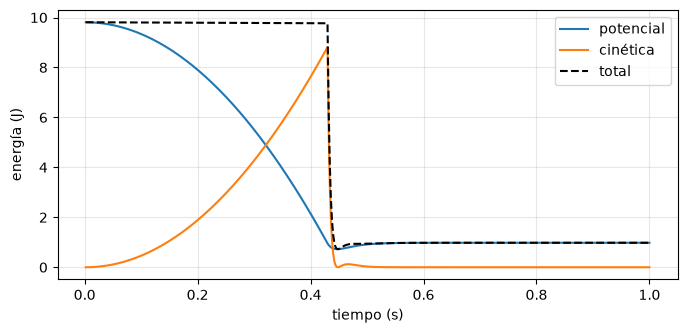

energía total al principio: 9.810 J,  justo antes del choque: 9.772 J,  al final: 0.980 J


In [29]:
import matplotlib.pyplot as plt

total = np.array(potencial) + np.array(cinetica)
plt.figure(figsize=(8, 3.5))
plt.plot(tiempos, potencial, label="potencial")
plt.plot(tiempos, cinetica, label="cinética")
plt.plot(tiempos, total, "k--", label="total")
plt.xlabel("tiempo (s)")
plt.ylabel("energía (J)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print(f"energía total al principio: {total[0]:.3f} J,  justo antes del choque: {total[200]:.3f} J,  al final: {total[-1]:.3f} J")

Tres momentos:

- **Al principio, 9,81 J**: 1 kg × 9,81 m/s² × 1 m de altura. Todo potencial.
- **Durante la caída**, la potencial (azul) baja y la cinética (naranja) sube... pero la **total** (la línea discontinua) **no** se queda perfectamente plana: baja un poquito, hasta **9,772 J** justo antes del choque. Se han "perdido" 0,04 J, un 0,4 %. En la física de verdad, sin rozamiento con el aire, la energía se conserva exactamente; aquí no, porque el ordenador avanza a **saltitos** de 0,002 s, y cada saltito comete un error minúsculo. Es el **error del integrador**, el mismo del NB07 (la pelota que caía 0,725 m en vez de 0,75). En el NB49 lo estudiaremos a fondo: cómo cambia con el pasito y con el integrador.
- **En el choque** (hacia los 0,43 s, que es lo que tarda en caer 0,9 m: √(2 × 0,9 / 9,81) = 0,428 s, NB07), la cinética desaparece **de golpe**, y la total se queda en **0,980 J**: justo la potencial de la caja **en reposo** sobre el suelo, con su centro a 0,1 m (1 × 9,81 × 0,1 = 0,981). Es decir: la caja **no rebota nada**. Toda su energía de movimiento se ha disipado en el contacto.

¿Es eso realista? Depende del material: una caja de madera casi no rebota; una pelota de goma, mucho. En MuJoCo, cuánto rebota un contacto se ajusta con el parámetro `solref` de los contactos, y por defecto está pensado para **no** rebotar (que es lo que conviene para los pies de un robot). Lo veremos en el NB48.

**Lección para la entrevista**: mirar la energía es una de las mejores herramientas para **depurar** una simulación. Si la energía total **sube** sin que nada la meta (ningún motor, ningún empujón), la simulación está **mal**: el pasito es demasiado grande, o hay algo inestable. Si baja un poco, es normal (contactos, amortiguadores, error del integrador).


## 9 · Python profesional: diseñar una clase de verdad

Hasta aquí hemos manejado `modelo` y `datos` sueltos, repitiendo siempre lo mismo: cargar, `mj_forward`, bucle de `mj_step`, copiar... En un proyecto de verdad, ese código se **organiza** en una clase. Y aprovechando, vamos a aprender las herramientas con las que un programador de Python profesional escribe clases hoy en día: **anotaciones de tipo**, **dataclasses**, **propiedades**, **métodos de clase** y **`__repr__`**.

### Anotaciones de tipo (*type hints*)

En el NB24 vimos que en Python una variable puede guardar cualquier cosa, y que eso es cómodo pero peligroso. Desde hace unos años, Python permite **anotar** qué tipo de cosa esperamos, con dos puntos y una flecha:


In [30]:
def energia_potencial(masa: float, altura: float, g: float = 9.81) -> float:
    return masa * g * altura

print(energia_potencial(23.6, 0.783))

181.27702800000003


- `masa: float` se lee "`masa` debería ser un número decimal".
- `-> float` se lee "esta función devuelve un número decimal".
- `g: float = 9.81` combina anotación y valor por defecto (NB23).

Lo **más importante** que hay que saber de las anotaciones: **Python no las comprueba**. Son **documentación** que el intérprete ignora al ejecutar:


In [31]:
print(energia_potencial("ja", 2, 3))      # masa = un TEXTO, g = un entero: Python no protesta

jajajajajaja


Ha devuelto `jajajajajaja`. Le hemos pasado un **texto** como masa, en contra de lo que dice la anotación, y Python no ha protestado: ha calculado `"ja" * 3 * 2`, y multiplicar un texto por un entero lo repite (NB20). Python **no miró** la anotación en ningún momento.

Entonces, ¿para qué sirven? Para tres cosas, y las tres importan en un trabajo:

1. **Leer el código.** `def paso(n: int) -> None` te dice de un vistazo qué entra y qué sale, sin leer el cuerpo de la función.
2. **El editor te ayuda.** VS Code, PyCharm... usan las anotaciones para autocompletar y para subrayar en rojo los errores **antes** de ejecutar: el `"ja"` de arriba saldría subrayado.
3. **Comprobadores automáticos.** Herramientas como **mypy** o **pyright** leen todo tu proyecto y te avisan de cada sitio donde los tipos no encajan, sin ejecutar nada. En muchas empresas, el código no se acepta si no pasa mypy.

Las anotaciones más comunes:

| Anotación | Significa |
|---|---|
| `int`, `float`, `str`, `bool` | los tipos básicos |
| `list[float]` | una lista de decimales |
| `dict[str, int]` | un diccionario de textos a enteros |
| `tuple[float, float]` | una tupla de exactamente dos decimales |
| `float \| None` | un decimal **o** `None` (Python 3.10 en adelante) |
| `np.ndarray` | un array de NumPy |
| `mujoco.MjModel` | un objeto de esa clase (¡cualquier clase sirve como tipo!) |


### Dataclasses: clases para guardar datos

En el NB24 escribimos clases a mano, con su `__init__` lleno de `self.x = x`. Para las clases cuyo trabajo principal es **guardar datos**, Python tiene un atajo profesional: el **decorador** `@dataclass` (los decoradores, a fondo, en el NB49; por ahora: una línea con `@` encima de una clase que la "mejora" automáticamente).

Vamos a hacer una **instantánea** del estado de una simulación: el tiempo, las posiciones y las velocidades:


In [32]:
from dataclasses import dataclass

@dataclass
class Instantanea:
    tiempo: float
    qpos: np.ndarray
    qvel: np.ndarray

foto = Instantanea(0.5, np.zeros(3), np.ones(3))
print(foto)
print(foto.tiempo)

Instantanea(tiempo=0.5, qpos=array([0., 0., 0.]), qvel=array([1., 1., 1.]))
0.5


Solo hemos escrito los **campos** con sus anotaciones de tipo, y `@dataclass` ha fabricado por nosotros:

- un **`__init__`** que recibe los tres campos en orden y los guarda (por eso funciona `Instantanea(0.5, ...)`);
- un **`__repr__`** que imprime la instancia de forma legible (`Instantanea(tiempo=0.5, qpos=..., ...)`) en vez del inútil `<__main__.Instantanea object at 0x7f...>` (NB24);
- un **`__eq__`** para comparar dos instancias con `==`, campo a campo.

En una dataclass, las anotaciones **sí** hacen algo: son las que le dicen a `@dataclass` cuáles son los campos. (El tipo sigue sin comprobarse.)

### Inmutables: frozen=True

Una instantánea del pasado **no debería cambiar**. Con `frozen=True` ("congelada"), la dataclass prohíbe reasignar sus campos:


In [33]:
@dataclass(frozen=True)
class Instantanea:
    tiempo: float
    qpos: np.ndarray
    qvel: np.ndarray

foto = Instantanea(0.5, np.zeros(3), np.ones(3))

In [34]:
foto.tiempo = 99.0

FrozenInstanceError: cannot assign to field 'tiempo'

Un `FrozenInstanceError`. Bien. Pero ojo, y esto es un detalle que separa a un profesional de un aficionado: **congelar la instantánea no congela los arrays de dentro**. El campo `qpos` no se puede **reasignar**, pero el array al que apunta sí se puede **modificar**:


In [35]:
foto.qpos[0] = 123.0          # no reasigna el campo: modifica el array por dentro
print(foto.qpos)

[123.   0.   0.]


Para que la instantánea sea de verdad intocable, hay que hacer dos cosas: guardar **copias** (si no, seguiríamos con el bug de la sección 5: ¡una instantánea que cambia sola!) y marcar esas copias como **de solo lectura** con `setflags(write=False)`. Lo haremos en un **método de clase** que fabrique la instantánea a partir de un `MjData` (en un momento lo explico):


In [36]:
@dataclass(frozen=True)
class Instantanea:
    tiempo: float
    qpos: np.ndarray
    qvel: np.ndarray

    @classmethod
    def de(cls, datos: mujoco.MjData) -> "Instantanea":
        qpos, qvel = datos.qpos.copy(), datos.qvel.copy()
        qpos.setflags(write=False)
        qvel.setflags(write=False)
        return cls(datos.time, qpos, qvel)

mujoco.mj_resetData(modelo, datos)
mujoco.mj_step(modelo, datos)
foto = Instantanea.de(datos)
print(foto.tiempo, foto.qpos[:3])

0.002 [ 0. -0. -0.]


In [37]:
foto.qpos[0] = 123.0

ValueError: assignment destination is read-only

Ahora sí: `ValueError: assignment destination is read-only`. La instantánea es una **foto** de verdad.

### @classmethod: constructores alternativos

`@classmethod` convierte un método en un **método de clase**: no recibe una instancia (`self`) como primer argumento, sino **la propia clase** (por convención, `cls`). Se llama sobre la clase, no sobre una instancia: `Instantanea.de(datos)`.

Su uso más típico es el de hoy: ofrecer **otras formas de construir** objetos. `__init__` recibe los campos tal cual; `de(datos)` sabe sacarlos de un `MjData`. Ya conocías uno: `mujoco.MjModel.from_xml_path(...)` y `from_xml_string(...)` son métodos de clase, ¡dos formas de construir un modelo!

¿Por qué `cls(...)` y no `Instantanea(...)`? Porque si alguien hace una clase hija de `Instantanea` (NB25), `cls` será la hija, y el método fabricará objetos de la hija. Es más general.

¿Y por qué la anotación de retorno va entre comillas, `-> "Instantanea"`? Porque mientras Python lee la clase, el nombre `Instantanea` **todavía no existe** (se está definiendo). Las comillas lo convierten en una **referencia adelantada**: "ya existirá". (Otra solución es poner `from __future__ import annotations` al principio del fichero, que hace eso con todas las anotaciones.)


### La trampa de == con arrays

Ya que estamos, otra trampa que muerde a mucha gente. El `__eq__` que fabrica `@dataclass` compara los campos **uno a uno**, encadenados con `and`: más o menos, `self.tiempo == otra.tiempo and self.qpos == otra.qpos and self.qvel == otra.qvel`. Pero con arrays de NumPy, `==` no da **un** `True` o `False`: da **un array** de `True`/`False`, casilla a casilla (NB15). Y `and` necesita saber si eso es "verdadero"... Mira lo que pasa al comparar dos instantáneas idénticas:


In [38]:
a = Instantanea(0.0, np.zeros(3), np.zeros(3))
b = Instantanea(0.0, np.zeros(3), np.zeros(3))
print(a == b)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

`ValueError: The truth value of an array with more than one element is ambiguous`: Python no sabe si "un array de tres `True`" cuenta como verdadero o falso (¿basta con que uno lo sea?, ¿hacen falta todos?), y en vez de adivinar, se niega. Es el mismo error que verías con `if np.zeros(3) == 0:`. Y fíjate en la línea del error: sale de un `__eq__` que **no escribiste tú** (`__create_fn__`): el que fabricó `@dataclass`.

Las soluciones profesionales:

- Comparar arrays siempre con **`np.array_equal(a, b)`** (iguales exactamente) o **`np.allclose(a, b)`** (casi iguales).
- En una dataclass con arrays, desactivar el `__eq__` automático con `@dataclass(eq=False)` y, si hace falta, escribir uno propio.

### slots=True: más ligeras

Una última opción de `@dataclass` que verás en código profesional: `slots=True`. Normalmente, cada objeto de Python guarda sus atributos en un diccionario interno (`__dict__`), lo que permite añadirle atributos nuevos en cualquier momento... y gasta memoria. Con `slots`, la clase declara de antemano sus atributos y no admite otros: los objetos ocupan menos y son algo más rápidos. Útil cuando creas **millones** de objetos pequeños (por ejemplo, una instantánea por paso de un entrenamiento largo).


### @property: atributos calculados

Ahora la clase grande: una **`Simulacion`** que junte modelo, datos y las operaciones de siempre. Antes, la última herramienta: **`@property`**. Convierte un método en algo que se **lee como un atributo**, sin paréntesis:


In [39]:
class Robot:
    def __init__(self, masas: list[float]):
        self.masas = masas

    @property
    def masa_total(self) -> float:
        return sum(self.masas)

r = Robot([12, 3, 2, 0.8, 3, 2, 0.8])
print(r.masa_total)            # sin paréntesis: parece un atributo, pero se calcula cada vez
r.masas.append(5)              # le añadimos una pieza de 5 kg...
print(r.masa_total)            # ...y la masa total se actualiza sola

23.6
28.6


¿Por qué no guardar `self.masa_total = sum(masas)` en el `__init__`? Porque se quedaría **desfasado** si cambian las masas (otra vez el problema de los valores "copiados" frente a los "calculados", como en la sección 2). Una propiedad se calcula **cada vez** que se lee, así que siempre está al día. Y desde fuera se usa igual que un atributo: quien usa la clase no necesita saber si el valor está guardado o se calcula.

Por la misma razón, una propiedad sin más es **de solo lectura**: `r.masa_total = 3` daría error. Es una buena forma de exponer valores que no deben tocarse desde fuera.

Si quieres que **sí** se pueda asignar, se le añade un segundo método, el ***setter***, con el decorador `@masa_total.setter`: Python lo llama automáticamente al escribir `r.masa_total = 3`, y dentro puedes hacer lo que quieras (comprobar que el valor tiene sentido, convertirlo...). Es exactamente el truco de `datos.ctrl` de la sección 5: MuJoCo programó un setter que **copia** los valores dentro de su memoria de C.


### La clase Simulacion

Juntamos todo. Fíjate en cómo cada herramienta tiene su papel:


In [40]:
class Simulacion:
    """Un modelo de MuJoCo y su estado, con las operaciones de siempre.

    Ejemplo:
        sim = Simulacion.desde_fichero("robots/zancudo.xml")
        sim.avanzar(500)
        print(sim.tiempo)
    """

    def __init__(self, modelo: mujoco.MjModel) -> None:
        self.modelo = modelo
        self.datos = mujoco.MjData(modelo)
        self.historia: list[Instantanea] = []
        mujoco.mj_forward(self.modelo, self.datos)       # nada de datos sin calcular (sección 6)

    @classmethod
    def desde_fichero(cls, ruta: str) -> "Simulacion":
        return cls(mujoco.MjModel.from_xml_path(ruta))

    @classmethod
    def desde_texto(cls, xml: str) -> "Simulacion":
        return cls(mujoco.MjModel.from_xml_string(xml))

    @property
    def tiempo(self) -> float:
        return self.datos.time

    @property
    def masa_total(self) -> float:
        return float(self.modelo.body_mass.sum())

    def reiniciar(self) -> None:
        mujoco.mj_resetData(self.modelo, self.datos)
        mujoco.mj_forward(self.modelo, self.datos)
        self.historia.clear()

    def avanzar(self, pasos: int = 1, guardar: bool = False) -> None:
        for _ in range(pasos):
            mujoco.mj_step(self.modelo, self.datos)
            if guardar:
                self.historia.append(Instantanea.de(self.datos))

    def __repr__(self) -> str:
        return (f"Simulacion(t={self.tiempo:.3f} s, nq={self.modelo.nq}, nv={self.modelo.nv}, "
                f"masa={self.masa_total:.1f} kg, {len(self.historia)} instantáneas)")

Repasemos las piezas nuevas:

- **La cadena de texto justo debajo de `class`** (entre tres comillas) es la **docstring** de la clase: su documentación. No es un comentario cualquiera: Python la guarda, y la muestran `help(Simulacion)` y los editores al pasar el ratón. Una buena docstring dice **qué hace** la clase y trae un **ejemplo de uso**. (En el NB46 veremos el formato de docstring profesional, el estilo NumPy.)
- **`self.historia: list[Instantanea] = []`**: se pueden anotar también los atributos. Aquí documenta que la historia es una lista de instantáneas.
- **Dos constructores alternativos** con `@classmethod`: desde un fichero o desde un texto XML.
- **Dos propiedades**: `tiempo` (que lee `datos.time`, siempre al día) y `masa_total`.
- **`for _ in range(pasos)`**: el guion bajo `_` es el nombre que se usa, por convención, para una variable que **no vamos a usar** (aquí solo queremos repetir, no nos importa el número de vuelta).
- **`__repr__`**: lo que se ve al imprimir la simulación. Escribirlo es un regalo para quien depura: un vistazo a la simulación sin abrirla. La convención es que parezca la forma de **construir** el objeto, o una descripción entre `<...>` o con el nombre de la clase y lo más importante.
- **`float(...)` en `masa_total`**: `body_mass.sum()` devuelve un número de NumPy (`np.float64`); `float()` lo convierte en un número normal de Python, como promete la anotación `-> float`. Un detalle de pulcritud.

Probémosla:


In [41]:
sim = Simulacion.desde_fichero("robots/zancudo.xml")
print(sim)
sim.datos.ctrl[:] = [0.3, -0.6, 0.3, 0.3, -0.6, 0.3]
sim.avanzar(500, guardar=True)
print(sim)
print("altura del torso al principio:", round(0.865 + sim.historia[0].qpos[1], 3),
      " y al final:", round(0.865 + sim.historia[-1].qpos[1], 3))

Simulacion(t=0.000 s, nq=9, nv=9, masa=23.6 kg, 0 instantáneas)
Simulacion(t=1.000 s, nq=9, nv=9, masa=23.6 kg, 500 instantáneas)
altura del torso al principio: 0.865  y al final: 0.815


Cuatro líneas para cargar, ordenar la postura agachada, simular un segundo guardando cada paso, e imprimir. Y la historia guarda **500 fotos independientes** (sin el bug de la sección 5): la altura de la cadera baja de 0,865 m a la de la postura agachada (NB43).

Esta clase crecerá a lo largo de la Parte 6: en el NB46 le añadiremos cinemática, en el NB47 controladores, en el NB49 medición de tiempos... Y en el NB54 la convertiremos en un **paquete** de Python instalable.


## 10 · ¿Cómo de rápido es MuJoCo?

Para acabar, una medida que todo ingeniero de simulación tiene que saber hacer: ¿cuántos pasos por segundo da tu simulación? Usamos `time.perf_counter()`, el reloj de alta precisión de Python, pensado justo para medir duraciones:


In [42]:
import time

sim.reiniciar()
n = 20_000
inicio = time.perf_counter()
sim.avanzar(n)
segundos = time.perf_counter() - inicio
print(f"{n / segundos:,.0f} pasos por segundo")
print(f"{n * sim.modelo.opt.timestep / segundos:.0f} veces más rápido que el tiempo real")

65,890 pasos por segundo
132 veces más rápido que el tiempo real


Unos **65.000 pasos por segundo** en la Raspberry Pi, con un solo núcleo: unas **130 veces más rápido que el tiempo real**. Un minuto de Zancudo se simula en menos de medio segundo.

(El `:,.0f` del f-string escribe el número sin decimales y con una coma cada tres cifras: `65,707`. Es el formato inglés; Python no pone el punto de los millares en español salvo que se lo pidas con el módulo `locale`.)

¿Mucho o poco? Para entrenar con RL hacen falta **millones** de pasos de decisión, y cada decisión de Zancudo son 10 pasitos de física (NB43): un millón de decisiones son 10 millones de pasitos, unos **2,5 minutos** solo de física. Pero el entrenamiento del NB43 tardó más de una hora por millón. ¿Dónde se va el resto del tiempo? En Python: el bucle, Gymnasium, la red neuronal de PPO... La física es la parte **barata**.

Dos lecciones para la entrevista:

1. **Mide antes de optimizar.** La intuición dice "la simulación es lo lento", y aquí es justo al revés. En el NB49 aprenderemos a medir **dónde** se va el tiempo (un **perfilador**, *profiler*) y a simular muchos robots en paralelo.
2. **Por eso existen MJX y las GPU** (NB59, NB60): no porque `mj_step` sea lento, sino porque, para hacer miles de millones de pasos, hay que quitar a Python de en medio y simular **miles** de robots a la vez.


## 11 · Resumen de la lección

1. **`MjModel`** = lo que no cambia (el plano: masas, formas, articulaciones, motores, opciones). **`MjData`** = lo que cambia (el estado) y todo lo calculado. Un modelo, muchos datos.
2. MuJoCo está escrito en **C**; Python es un envoltorio. Los arrays de `MjData` son **vistas** a memoria de C.
3. Acceso por nombre: `modelo.body("torso")`, `datos.joint("rodilla_d").qpos`... Mejor que los números.
4. **Coordenadas generalizadas** `qpos`/`qvel`. **nq ≠ nv** cuando hay articulaciones libres (7/6) o rótulas (4/3): la orientación 3D se guarda con un **cuaternión** (4 números, sin bloqueo de cardán), pero su velocidad de giro necesita solo 3. Usa siempre `qposadr`/`dofadr` o los nombres.
5. **Estado** = `qpos`, `qvel`, `act`, `time`. `mj_getState`/`mj_setState`: viajar en el tiempo. MuJoCo es **determinista**.
6. **Vistas y copias**: guarda con `.copy()`; modifica en el sitio con `[:]`; `copy.copy(datos)` da un gemelo independiente.
7. **`mj_step` = `mj_forward` + integrar**. Cinco etapas: posición (cinemática, M, colisiones), velocidad (sesgo, pasivas), actuación, aceleración (con el solucionador de restricciones) e integración (Euler **semiimplícito**). `mj_kinematics` coloca las piezas; tras cambiar `qpos` a mano, calcula antes de leer.
8. **M(q)q̈ + c(q,q̇) = τ + Jᵀf**, comprobada con un error de 10⁻¹³. M es simétrica y definida positiva; su diagonal es la "masa" de cada articulación (23,6 kg para avanzar el robot entero). En reposo, el sesgo es la gravedad: 231,516 N = el peso.
9. **Energía**: potencial y cinética; en caída libre la total baja un 0,4 % por el error del integrador; en el choque, la caja pierde toda su energía cinética. Si la energía **sube** sola, la simulación está mal.
10. Python profesional: **anotaciones de tipo** (documentación, no se comprueban al ejecutar; mypy), **dataclasses** (`frozen`, `slots`, la trampa de `==` con arrays), **`@classmethod`** (constructores alternativos), **`@property`** (atributos calculados), **`__repr__`**, docstrings, banderas de bits (`|`, `&`, `~`), `time.perf_counter`.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **MjModel / MjData** | El modelo (lo que no cambia) / los datos (estado y todo lo calculado). |
| **Envoltorio (*bindings*)** | Capa que deja a un lenguaje (Python) usar una biblioteca escrita en otro (C). |
| **Coordenadas generalizadas** | Los números mínimos que describen la postura: `qpos` (y `qvel`). |
| **Grado de libertad (*dof*)** | Cada forma independiente de moverse; `nv` es su número. |
| **Cuaternión** | 4 números que describen una orientación 3D sin bloqueo de cardán. |
| **Bloqueo de cardán (*gimbal lock*)** | Posturas en que 3 ángulos pierden un grado de libertad. |
| **Estado** | Lo necesario para que la simulación siga igual: `qpos`, `qvel`, `act`, `time`. |
| **Determinista** | Mismo estado y mismas órdenes → exactamente el mismo resultado. |
| **Vista / copia** | Array que mira la memoria de otro / array con sus propios números. |
| **Dinámica directa / inversa** | Fuerzas → aceleración (simular) / aceleración deseada → fuerzas (controlar). |
| **Matriz de masas M(q)** | La "masa" de cada articulación y sus acoplamientos. Simétrica y definida positiva. |
| **Fuerzas de sesgo** | Gravedad + efectos de los giros (centrífugos, Coriolis). |
| **Euler semiimplícito** | Actualiza primero la velocidad y usa la nueva para la posición: más estable. |
| **Anotación de tipo (*type hint*)** | `x: float`, `-> int`: documentación del tipo esperado. |
| **Dataclass** | Clase para guardar datos; Python le fabrica `__init__`, `__repr__`, `__eq__`. |
| **`@classmethod` / `@property`** | Método de la clase (constructores alternativos) / método que se lee como atributo. |
| **Bandera de bits** | Un entero cuyos bits son interruptores; `\|` enciende, `& ~` apaga, `&` pregunta. |


## 12 · Ejercicios

**E1.** ¿Cuánto valen `nq` y `nv` para un humanoide con una articulación libre en la pelvis, 2 rótulas (hombros) y 19 bisagras? ¿En qué casilla de `qpos` empieza la primera rótula? ¿Y de `qvel`?

**E2.** El bug de la sección 5, con otra cara: ejecuta `fotos = [datos.xpos] * 3` y luego `mujoco.mj_step(modelo, datos)`. ¿Las tres fotos son iguales a `datos.xpos`? ¿Y si haces `[datos.xpos.copy()] * 3`? ¿Son tres copias independientes **entre sí**?

**E3.** Con la caja de la sección 8, repite la caída con `timestep` de **0,0005** (cuatro veces más pequeño). ¿Cuánta energía se "pierde" ahora antes del choque? (Pista: `caja.opt.timestep = 0.0005`.)

**E4.** Comprueba con números la ecuación del movimiento de Zancudo **mientras cae** (sin motores: `modelo.opt.disableflags` con `mujoco.mjtDisableBit.mjDSBL_ACTUATION`), justo después de inclinarlo 0,3 rad. ¿Qué pasa con `qfrc_constraint` antes de que toque el suelo?

**E5.** Añade a `Simulacion` una propiedad `centro_de_masas` (la posición del CdM de todo el robot) y un método `instantanea_mas_alta()` que devuelva la `Instantanea` de la historia en que la raíz estaba más alta. (Pista: `max` con `key=`, NB23.)

**E6.** **Reto.** Escribe una función `viajar(sim, indice)` que devuelva la simulación al momento de la instantánea número `indice` de su historia. La historia no guarda el estado en el formato de `mj_getState`, así que hazlo a mano: copia `qpos`, `qvel` y el tiempo de la instantánea dentro de `sim.datos` y llama a `mj_forward`. Comprueba que, desde ahí, volver a simular reproduce la historia **bit a bit**.


<details>
<summary>▶ Solución E1</summary>

- Libre: 7 en `qpos`, 6 en `qvel`. Cada rótula: 4 y 3. Cada bisagra: 1 y 1.
- `nq` = 7 + 2 × 4 + 19 × 1 = **34**. `nv` = 6 + 2 × 3 + 19 = **31**.
- Si la libre va primero (siempre es así: es la raíz del árbol), la primera rótula empieza en la casilla **7** de `qpos` y en la **6** de `qvel`. (Si hubiera bisagras **antes** de la rótula en el árbol, habría que sumarlas; por eso mejor `jnt_qposadr`.)
</details>

<details>
<summary>▶ Solución E2</summary>

```python
mujoco.mj_resetData(modelo, datos)
mujoco.mj_forward(modelo, datos)
fotos = [datos.xpos] * 3
mujoco.mj_step(modelo, datos)
print(all(f is datos.xpos for f in fotos))           # True: las tres SON datos.xpos

fotos = [datos.xpos.copy()] * 3
print(fotos[0] is fotos[1])                          # True: ¡las tres son LA MISMA copia!
```

Con `[x] * 3`, Python crea una lista con **tres referencias al mismo objeto** (NB21). En el primer caso, las tres son la vista `datos.xpos`. En el segundo, hay **una** copia (independiente de `datos`), pero las tres casillas de la lista la comparten: si modificas `fotos[0][1, 2] = 5`, verás el 5 en las tres. Para tres copias independientes: `[datos.xpos.copy() for _ in range(3)]`.
</details>

<details>
<summary>▶ Solución E3</summary>

```python
caja.opt.timestep = 0.0005
mujoco.mj_resetData(caja, datos_caja)
totales = []
while datos_caja.time < 0.42:                # antes del choque
    mujoco.mj_step(caja, datos_caja)
    totales.append(datos_caja.energy.sum())
print(totales[0], totales[-1])
caja.opt.timestep = 0.002                    # dejarlo como estaba
```

Ahora la total pasa de 9,81 a unos **9,80 J**: se pierde unas **cuatro veces menos** energía. El error de Euler es proporcional al pasito: pasito 4 veces más pequeño, error 4 veces más pequeño (a cambio, 4 veces más pasos de cálculo). En el NB49 veremos integradores cuyo error baja mucho más deprisa.
</details>

<details>
<summary>▶ Solución E4</summary>

```python
modelo.opt.disableflags |= mujoco.mjtDisableBit.mjDSBL_ACTUATION
mujoco.mj_resetData(modelo, datos)
datos.qpos[1] = 0.2                       # lo subimos 20 cm, para que caiga sin tocar el suelo
datos.qpos[2] = 0.3
mujoco.mj_forward(modelo, datos)
mujoco.mj_fullM(modelo, datos, M)
izquierda = M @ datos.qacc + datos.qfrc_bias
derecha = datos.qfrc_actuator + datos.qfrc_passive + datos.qfrc_constraint + datos.qfrc_applied
print(np.abs(izquierda - derecha).max(), datos.qfrc_constraint, datos.ncon)
modelo.opt.disableflags &= ~int(mujoco.mjtDisableBit.mjDSBL_ACTUATION)   # volver a encender los motores
```

La ecuación se cumple igual (error ~10⁻¹⁴). Con el robot en el aire, no hay contactos (`ncon = 0`) y `qfrc_constraint` es **cero**: solo quedan la gravedad (sesgo) y la masa. La aceleración de la raíz vertical es −9,81: caída libre. Fíjate en el uso de `|=` para apagar los motores y de `&= ~` para volver a encenderlos (sección 8). Y en un detalle: `~mujoco.mjtDisableBit.mjDSBL_ACTUATION` da un `TypeError`, porque los enums de MuJoCo no saben invertirse; hay que convertirlo antes en un entero normal con `int(...)`.
</details>

<details>
<summary>▶ Solución E5</summary>

```python
class SimulacionPlus(Simulacion):          # herencia (NB25): reutilizamos todo
    @property
    def centro_de_masas(self) -> np.ndarray:
        return self.datos.subtree_com[0].copy()      # el cuerpo 0 (el mundo) "contiene" todo el robot

    def instantanea_mas_alta(self) -> Instantanea:
        return max(self.historia, key=lambda foto: foto.qpos[1])

sim2 = SimulacionPlus.desde_fichero("robots/zancudo.xml")
sim2.avanzar(300, guardar=True)
print(sim2.centro_de_masas, sim2.instantanea_mas_alta().tiempo)
```

Dos detalles: el CdM se devuelve **copiado** (si devolviéramos la vista, quien lo guarde tendría el bug de la sección 5), y `max(..., key=...)` compara las instantáneas por la altura de la raíz (`qpos[1]`) sin tener que escribir el bucle. Fíjate también en que `desde_fichero` (heredado) fabrica una `SimulacionPlus` y no una `Simulacion`: es gracias al `cls(...)` del método de clase.
</details>

<details>
<summary>▶ Solución E6</summary>

```python
def viajar(sim: Simulacion, indice: int) -> None:
    foto = sim.historia[indice]
    sim.datos.qpos[:] = foto.qpos          # [:] : escribir DENTRO de la memoria de MuJoCo
    sim.datos.qvel[:] = foto.qvel
    sim.datos.time = foto.tiempo
    mujoco.mj_forward(sim.modelo, sim.datos)

sim.reiniciar()
sim.avanzar(400, guardar=True)
original = sim.historia[399].qpos
viajar(sim, 199)                           # al final del paso 200
sim.historia = sim.historia[:200]          # descartamos el "futuro"
sim.avanzar(200, guardar=True)
print(np.array_equal(sim.historia[399].qpos, original))     # False
print(np.abs(sim.historia[399].qpos - original).max())     # ~6e-18
```

¡**No** reproduce bit a bit! La diferencia es minúscula (unos 6 × 10⁻¹⁸ m, mucho menos que el tamaño de un átomo), pero existe. Es el **warmstart** de la sección 4: la instantánea no guarda `qacc_warmstart`, así que el solucionador de contactos arranca, en el paso 201, desde la aceleración que tenía `datos` al final del paso 400, no desde la del paso 200.

La solución es guardar también el warmstart. Como `Instantanea` es una dataclass, podemos hacer una hija con un campo más (NB25):

```python
@dataclass(frozen=True)
class InstantaneaCompleta(Instantanea):
    warmstart: np.ndarray = None

    @classmethod
    def de(cls, datos: mujoco.MjData) -> "InstantaneaCompleta":
        base = Instantanea.de(datos)
        return cls(base.tiempo, base.qpos, base.qvel, datos.qacc_warmstart.copy())
```

y en `viajar`, añadir `sim.datos.qacc_warmstart[:] = foto.warmstart`. Con eso, `np.array_equal` da **True**. (O, más sencillo: guardar en cada paso el `mj_getState` con `mjSTATE_INTEGRATION`.)

Ojo también con `ctrl`: no forma parte del estado físico. Aquí `reiniciar` lo dejó a cero y no lo tocamos; si la política cambiara `ctrl` en cada paso, habría que repetir también las mismas órdenes.
</details>


## 13 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

En el **NB46** seguimos dentro de MuJoCo con la **cinemática**: cómo se describen posiciones y giros en 3D (matrices de rotación, cuaterniones de verdad, ángulos de Euler), qué es un **jacobiano** (la J de la ecuación de hoy) y cómo se usa para la **cinemática inversa**: "quiero el pie aquí; ¿qué ángulos pongo?". Y en el hilo de Python: NumPy para álgebra lineal a fondo, funciones puras, docstrings profesionales y pruebas con pytest.
